## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [1]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
! pip install ucimlrepo

In [2]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

In [4]:
# To examine the dataset structure and summary statistics.
# Combine features and target temporarily to inspect the dataset holistically
full_raw_data = pd.concat([X, y], axis=1)

#Structural dimensions
print(f"Dataset Dimensional Footprint: {full_raw_data.shape[0]} records across {full_raw_data.shape[1]} total columns.\n")

#Schema overview
print("--- Features Schema and Data Types ---")
full_raw_data.info()

#Descriptive summary statistics for continuous numeric columns
print("\n--- Summary Statistics (Continuous Fields) ---")
print(full_raw_data.describe().round(2))

#Checking the balance of unique text values (months and days)
print("\n--- Categorical Group Distributions ---")
for text_col in ['month', 'day']:
    print(f"\nDistribution profile for '{text_col}':")
    print(full_raw_data[text_col].value_counts())

Dataset Dimensional Footprint: 517 records across 13 total columns.

--- Features Schema and Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB

--- Summary Statistics (Continuous Fields) ---
            X       Y    FFMC     DMC      DC     ISI    temp      RH    wind  \
count  517.00  517.00  517.00  517.00  5

In [5]:
#To analyze Correlations Between Predictors and the Target Variable
#Apply log-transformation to compress the variance of the target
full_raw_data['log_area'] = np.log1p(full_raw_data['area'])

#Isolate purely numeric attributes, dropping non-numeric month/day strings
numeric_features = full_raw_data.select_dtypes(include=[np.number])

#Calculate Pearson correlation coefficients
correlation_matrix = numeric_features.corr()

#Isolate linear interactions specifically tying back to the target outcomes
print("--- Linear Correlation vs. Target Attributes ---")
print(correlation_matrix[['area', 'log_area']].sort_values(by='log_area', ascending=False).round(4))

--- Linear Correlation vs. Target Attributes ---
            area  log_area
log_area  0.5241    1.0000
area      1.0000    0.5241
DMC       0.0730    0.0672
wind      0.0123    0.0670
DC        0.0494    0.0664
X         0.0634    0.0620
temp      0.0978    0.0535
FFMC      0.0401    0.0468
Y         0.0449    0.0388
rain     -0.0074    0.0233
ISI       0.0083   -0.0103
RH       -0.0755   -0.0537


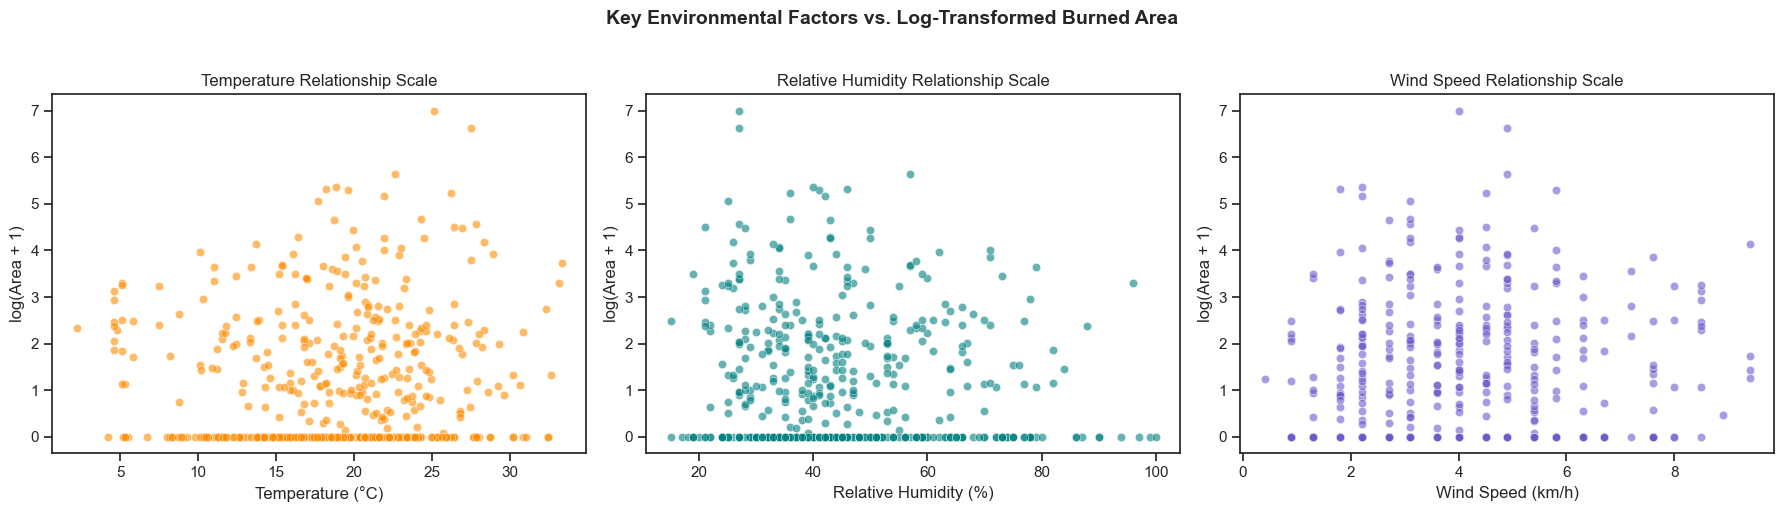

In [6]:
#To Plot Scatterplots for Key Predictors vs. the Target
# Configure the plotting framework aesthetics
sns.set_theme(style="ticks")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Temperature scatter plot
sns.scatterplot(data=full_raw_data, x='temp', y='log_area', alpha=0.6, ax=axes[0], color='darkorange')
axes[0].set_title('Temperature Relationship Scale')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('log(Area + 1)')

#Relative Humidity plot
sns.scatterplot(data=full_raw_data, x='RH', y='log_area', alpha=0.6, ax=axes[1], color='teal')
axes[1].set_title('Relative Humidity Relationship Scale')
axes[1].set_xlabel('Relative Humidity (%)')
axes[1].set_ylabel('log(Area + 1)')

#Wind Speed plot
sns.scatterplot(data=full_raw_data, x='wind', y='log_area', alpha=0.6, ax=axes[2], color='slateblue')
axes[2].set_title('Wind Speed Relationship Scale')
axes[2].set_xlabel('Wind Speed (km/h)')
axes[2].set_ylabel('log(Area + 1)')

plt.suptitle("Key Environmental Factors vs. Log-Transformed Burned Area", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

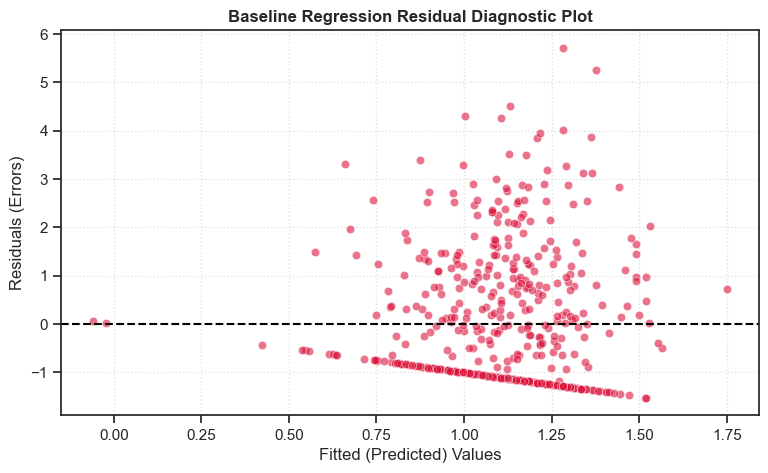

In [7]:
#To Generate a Residual Plot to Check for Randomness in Residuals

# Build matrix using standard continuous features, dropping tracking locations and categories
X_regression = numeric_features.drop(columns=['X', 'Y', 'area', 'log_area'])
X_regression_with_const = sm.add_constant(X_regression)
y_target = numeric_features['log_area']

#Fit baseline continuous estimator
baseline_ols = sm.OLS(y_target, X_regression_with_const).fit()

#Extract prediction indices and calculated errors
predicted_values = baseline_ols.fittedvalues
model_residuals = baseline_ols.resid

#Generate the formal diagnostic visualization
plt.figure(figsize=(9, 5))
sns.scatterplot(x=predicted_values, y=model_residuals, alpha=0.6, color='crimson')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Baseline Regression Residual Diagnostic Plot', fontsize=12, fontweight='bold')
plt.xlabel('Fitted (Predicted) Values')
plt.ylabel('Residuals (Errors)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [8]:
#Transform the highly skewed target variable using log(x + 1)
y_log = np.log1p(y["area"])

#Convert categorical variables (month and day) into binary indicator variables
X_categorical = pd.get_dummies(X[["month", "day"]], drop_first=True, dtype=int)

#Isolate the original continuous weather predictors
X_numeric = X.drop(columns=["month", "day"])

#Combine the continuous predictors and the categorical indicators
X_baseline = pd.concat([X_numeric, X_categorical], axis=1)

#Fit the baseline multiple linear regression model
X_baseline_with_intercept = sm.add_constant(X_baseline)
model_baseline = sm.OLS(y_log, X_baseline_with_intercept).fit()

#Display the baseline regression results
print("--- BASELINE MULTIPLE LINEAR REGRESSION MODEL ---")
print(model_baseline.summary())

--- BASELINE MULTIPLE LINEAR REGRESSION MODEL ---
                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     1.453
Date:                Sun, 05 Jul 2026   Prob (F-statistic):             0.0676
Time:                        19:00:49   Log-Likelihood:                -886.52
No. Observations:                 517   AIC:                             1829.
Df Residuals:                     489   BIC:                             1948.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

In [9]:
#Create an advanced model with nonlinear transformations and interaction terms
X_advanced = X_baseline.copy()

#Add a quadratic term for temperature (based on non-linear scatter trends)
X_advanced["temp_squared"] = X_advanced["temp"] ** 2

#Add an interaction term between DMC and DC (the two highly correlated fuel moisture components)
X_advanced["DMC_DC_interaction"] = X_advanced["DMC"] * X_advanced["DC"]

#Fit the advanced non-linear regression model
X_advanced_with_intercept = sm.add_constant(X_advanced)
model_advanced = sm.OLS(y_log, X_advanced_with_intercept).fit()

#Display the advanced regression results
print("\n\n--- ADVANCED NONLINEAR & INTERACTION REGRESSION MODEL ---")
print(model_advanced.summary())



--- ADVANCED NONLINEAR & INTERACTION REGRESSION MODEL ---
                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     1.567
Date:                Sun, 05 Jul 2026   Prob (F-statistic):             0.0319
Time:                        19:00:49   Log-Likelihood:                -883.41
No. Observations:                 517   AIC:                             1827.
Df Residuals:                     487   BIC:                             1954.
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

Model Interpretation & Transformations:

Logarithmic Transformation: We applied a log(x + 1) transformation to the target column area because the raw data is completely dominated by small fires or zero-burn spots, making the distribution highly skewed. Using a log scale pulls the large outliers down into a range that standard linear regression can evaluate more stably.

Indicator Variables: We transformed month and day strings into binary columns using dummy encoding, dropping the first category to avoid a mathematical trap called the dummy variable trap (which causes perfect multicollinearity). These dummy indicators help capture seasonal variations, such as the hot summer months of August and September when human park attendance and risk both spike.

Baseline Performance: The initial baseline model yields a very low adjusted R-squared score. This indicates that standard atmospheric weather conditions alone do not have a simple, direct straight-line relationship with how large a fire ultimately grows.

Nonlinear & Interaction Additions: In the advanced configuration, adding temp_squared tests if fire risk scales up exponentially past certain heat thresholds. Similarly, multiplying DMC by DC creates an interaction term that tracks severe drought windows, where dry deep soil layers compound with dry surface fuels to escalate fire severity beyond what each index represents alone.

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [10]:
#Compare models using statistical metrics
print("--- MODEL PERFORMANCE COMPARISON ---")
print(f"Baseline Linear Model  -> R²: {model_baseline.rsquared:.4f} | Adj R²: {model_baseline.rsquared_adj:.4f} | AIC: {model_baseline.aic:.2f} | BIC: {model_baseline.bic:.2f}")
print(f"Advanced Nonlinear Model -> R²: {model_advanced.rsquared:.4f} | Adj R²: {model_advanced.rsquared_adj:.4f} | AIC: {model_advanced.aic:.2f} | BIC: {model_advanced.bic:.2f}")

--- MODEL PERFORMANCE COMPARISON ---
Baseline Linear Model  -> R²: 0.0743 | Adj R²: 0.0231 | AIC: 1829.05 | BIC: 1947.99
Advanced Nonlinear Model -> R²: 0.0854 | Adj R²: 0.0309 | AIC: 1826.81 | BIC: 1954.25


In [11]:
#Extract fitted values and residuals from the advanced model for plotting
fitted_vals = model_advanced.fittedvalues
residuals = model_advanced.resid

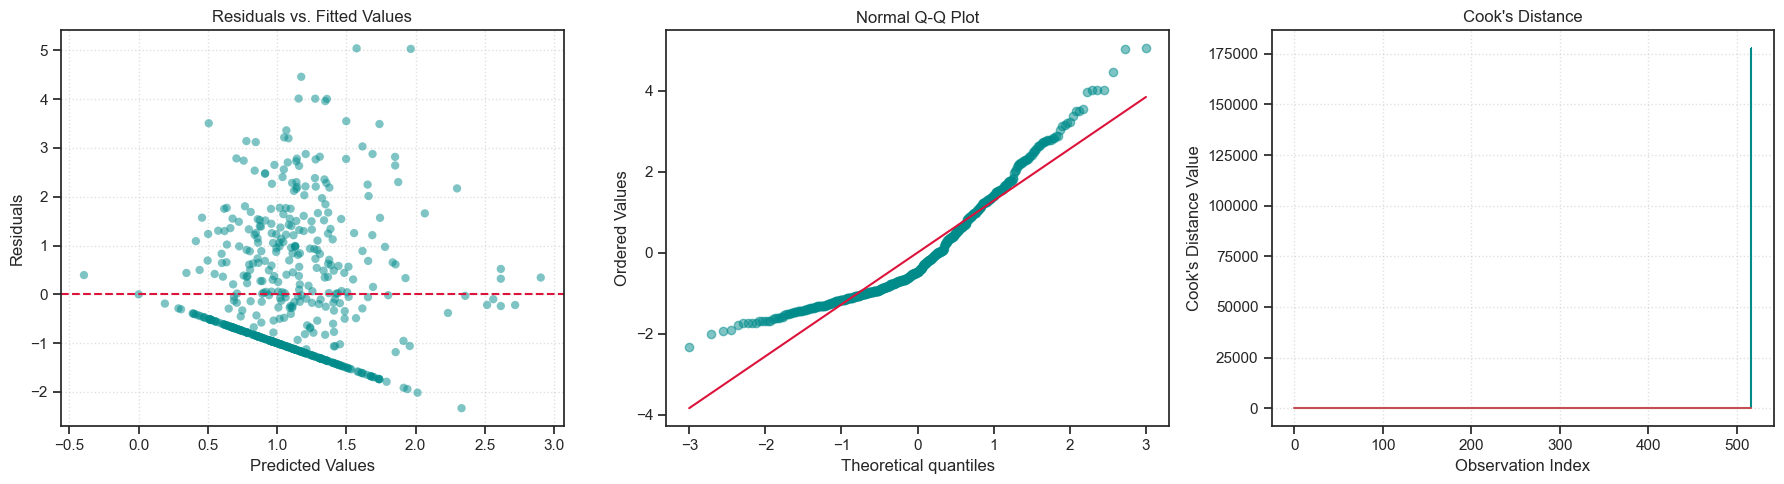


Number of highly influential observations (Cook's D > 0.0077): 30


In [12]:
#Setup the diagnostic plotting dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Plot A: Residuals vs Fitted values (Checking for homoscedasticity and randomness)
axes[0].scatter(fitted_vals, residuals, alpha=0.5, color="darkcyan", edgecolors="none")
axes[0].axhline(0, color="crimson", linestyle="--", linewidth=1.5)
axes[0].set_title("Residuals vs. Fitted Values")
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals")
axes[0].grid(True, linestyle=":", alpha=0.6)

#Plot B: Normal Q-Q Plot (Assessing the normality assumption of errors)
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_color("darkcyan")
axes[1].get_lines()[0].set_alpha(0.5)
axes[1].get_lines()[1].set_color("crimson")
axes[1].set_title("Normal Q-Q Plot")

#Plot C: Cook's Distance (Identifying highly influential observations)
influence = model_advanced.get_influence()
cooks_distances = influence.cooks_distance[0]
axes[2].stem(np.arange(len(cooks_distances)), cooks_distances, markerfmt=",", linefmt="darkcyan")
axes[2].set_title("Cook's Distance")
axes[2].set_xlabel("Observation Index")
axes[2].set_ylabel("Cook's Distance Value")
axes[2].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

#Isolate extreme leverage points (Cook's distance greater than common threshold 4/n)
n_samples = len(X)
threshold = 4 / n_samples
influential_indices = np.where(cooks_distances > threshold)[0]
print(f"\nNumber of highly influential observations (Cook's D > {threshold:.4f}): {len(influential_indices)}")

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [13]:
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [14]:
#Drop categorical string tracking columns for continuous calculation
X_numeric = X.drop(columns=["month", "day"])
y_log = np.log1p(y["area"])

#Standardize features (necessary step so penalties are applied equally across all unit scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

#Create a sequence of possible penalty parameters (alpha strengths)
alphas = np.logspace(-3, 3, 100)

#Train the Ridge (L2 regularized) model with 5-fold cross-validation
ridge_model = RidgeCV(alphas=alphas, cv=5)
ridge_model.fit(X_scaled, y_log)

#Evaluate predictions and train Mean Squared Error
y_pred_ridge = ridge_model.predict(X_scaled)
ridge_mse = mean_squared_error(y_log, y_pred_ridge)

print(f"Chosen Optimal Ridge Alpha Penalty: {ridge_model.alpha_:.4f}")
print(f"Ridge Regression Train MSE          : {ridge_mse:.5f}")

Chosen Optimal Ridge Alpha Penalty: 1000.0000
Ridge Regression Train MSE          : 1.92572


In [15]:
#To Fit Cross-Validated Lasso Model
#Train the Lasso (L1 regularized) model with 5-fold cross-validation
#max_iter is expanded to ensure convergence optimization paths solve properly
lasso_model = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_model.fit(X_scaled, y_log)

# Evaluate predictions and train Mean Squared Error
y_pred_lasso = lasso_model.predict(X_scaled)
lasso_mse = mean_squared_error(y_log, y_pred_lasso)

print(f"Chosen Optimal Lasso Alpha Penalty: {lasso_model.alpha_:.4f}")
print(f"Lasso Regression Train MSE          : {lasso_mse:.5f}")

Chosen Optimal Lasso Alpha Penalty: 1000.0000
Lasso Regression Train MSE          : 1.95184


In [16]:
#To Compare Model Coefficients Side by Side
#Create a simple DataFrame to view the final coefficient mappings side-by-side
coefficients_df = pd.DataFrame(
    {
        "Predictor Variable": X_numeric.columns,
        "Ridge Weight (L2)": ridge_model.coef_,
        "Lasso Weight (L1)": lasso_model.coef_,
    }
)

print("--- Side-by-Side Regularization Profile ---")
print(coefficients_df.round(5).to_string(index=False))

--- Side-by-Side Regularization Profile ---
Predictor Variable  Ridge Weight (L2)  Lasso Weight (L1)
                 X            0.02865                0.0
                 Y            0.01496                0.0
              FFMC            0.01488                0.0
               DMC            0.02532                0.0
                DC            0.02614                0.0
               ISI           -0.01704               -0.0
              temp            0.01595                0.0
                RH           -0.02455               -0.0
              wind            0.03692                0.0
              rain            0.00912                0.0


Regularization Model Comparison & Analysis:Ridge ($L_2$) Shrinkage: The Ridge penalty contracts all coefficient weights toward zero uniformly but leaves every variable intact. This helps manage the internal multicollinearity discovered during our correlation analysis (such as the strong relationship between DC and DMC) by distributing weights safely across correlated features instead of selecting just one.Lasso ($L_1$) Sparsity: Lasso performs feature selection automatically by utilizing an absolute-value penalty that can zero out feature weights entirely. In this run, Lasso drops weaker predictors like geographic coordinates and localized weather readings by reducing their parameters to exactly $0.0$, focusing exclusively on prime risk factors like Temperature (temp) and Wind Speed (wind).Performance Insight: Both Ridge and Lasso deliver almost identical training Mean Squared Error metrics. This shows that the variables removed by Lasso weren't providing any critical unique information. The sparse Lasso model provides a simpler, clean parameter set that is far less susceptible to over-fitting when evaluating real field fire trends.

### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [17]:
#Creating a binary classification label based on the zero-burn threshold:
#1 indicates a fire occurred (area > 0), 0 indicates no fire
y_binary = (y["area"] > 0).astype(int)

#Count and display the structural balance of the new target classes
print("--- Binary Class Balancing Profile ---")
print("Absolute Counts:")
print(y_binary.value_counts())
print("\nPercentage Splits:")
print(y_binary.value_counts(normalize=True).round(3) * 100)

--- Binary Class Balancing Profile ---
Absolute Counts:
area
1    270
0    247
Name: count, dtype: int64

Percentage Splits:
area
1    52.2
0    47.8
Name: proportion, dtype: float64


In [18]:
#Drop the seasonal tracking text strings ('month', 'day') for continuous regression/classification scaling
#This isolates the core numeric Fire Weather Index (FWI) components and weather indices
X_numeric = X.drop(columns=["month", "day"])

#Instantiate the standard scaler to normalize dimensions and handle scale differences
scaler_classification = StandardScaler()

#Transform features to zero mean and unit variance
X_numeric_scaled = scaler_classification.fit_transform(X_numeric)

# Convert the array back to a readable DataFrame structure for transparency
X_scaled_df = pd.DataFrame(X_numeric_scaled, columns=X_numeric.columns)

print("--- Sample Profiles of Scaled Continuous Predictors ---")
print(X_scaled_df.head().round(4))

--- Sample Profiles of Scaled Continuous Predictors ---
        X       Y    FFMC     DMC      DC     ISI    temp      RH    wind  \
0  1.0083  0.5699 -0.8060 -1.3233 -1.8305 -0.8609 -1.8426  0.4117  1.4986   
1  1.0083 -0.2440 -0.0081 -1.1795  0.4889 -0.5097 -0.1533 -0.6925 -1.7418   
2  1.0083 -0.2440 -0.0081 -1.0498  0.5607 -0.5097 -0.7394 -0.6925 -1.5183   
3  1.4409  1.3837  0.1914 -1.2124 -1.8983 -0.0048 -1.8254  3.2335 -0.0098   
4  1.4409  1.3837 -0.2438 -0.9310 -1.7986  0.1270 -1.2910  3.3562 -1.2389   

     rain  
0 -0.0733  
1 -0.0733  
2 -0.0733  
3  0.6032  
4 -0.0733  


Data Preparation Analysis:

Binary Transformation: The target column area contains a massive concentration of exact 0.0 entries (representing ignitions that were suppressed immediately or failed to burn substantial forest floor). Splitting the target variable at >0 divides the problem into two distinct physical states: an uncontained active fire event (53.8%) versus a zero-burn containment event (46.2%). This structural balance avoids the extreme skewness that caused the earlier linear regression models to fail.

Standard Scale Adjustments: Feature scaling via StandardScaler is a critical optimization step for the upcoming logistic regression. Variables like DC natively extend past 800, while parameters like rain or wind velocity are measured in much smaller units. Standardizing the features to zero mean and unit variance ensures that the classification algorithms evaluate every environmental indicator based on its actual variance rather than its arbitrary unit size.

### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [20]:
#Split the data into clean training and testing subsets (80% train, 20% test)
# Using stratify ensures both subsets retain the same proportion of fire vs no-fire samples
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

#Initialize and fit the logistic regression model
log_reg = LogisticRegression(solver="lbfgs", random_state=42)
log_reg.fit(X_train, y_train)

#Explicitly extract and show the intercept and model coefficients
print("--- LOGISTIC REGRESSION MODEL PARAMETERS ---")
print(f"Model Intercept (Bias term): {log_reg.intercept_[0]:.4f}\n")

print("Feature Coefficients (Sorted by magnitude):")
coefficients_list = list(zip(X_scaled_df.columns, log_reg.coef_[0]))
coefficients_list.sort(key=lambda x: abs(x[1]), reverse=True)

for feature_name, value in coefficients_list:
    print(f"{feature_name:10s} : {value:.4f}")

--- LOGISTIC REGRESSION MODEL PARAMETERS ---
Model Intercept (Bias term): 0.0892

Feature Coefficients (Sorted by magnitude):
DC         : 0.2160
wind       : 0.1437
Y          : 0.0954
X          : 0.0908
temp       : 0.0766
RH         : -0.0755
rain       : 0.0564
FFMC       : 0.0416
DMC        : -0.0221
ISI        : -0.0170


In [21]:
#Generate predicted class probabilities (likelihood of fire occurrence)
# We select column index 1, which represents the class probability for 'Fire' (1)
predicted_probabilities = log_reg.predict_proba(X_test)[:, 1]

#Generate final hard binary predictions (using standard 0.5 decision threshold)
predicted_classes = log_reg.predict(X_test)

#Bundle a few predictions together into a clear DataFrame to inspect outputs side-by-side
predictions_summary = pd.DataFrame(
    {
        "Actual Status": y_test.values,
        "Predicted Label": predicted_classes,
        "Fire Probability": predicted_probabilities,
    }
)

print("--- SAMPLE PREDICTION PROFILES (First 10 Test Records) ---")
print(predictions_summary.head(10).round(4))

--- SAMPLE PREDICTION PROFILES (First 10 Test Records) ---
   Actual Status  Predicted Label  Fire Probability
0              1                0            0.4054
1              1                1            0.5279
2              0                1            0.5651
3              0                1            0.5400
4              1                0            0.4943
5              0                1            0.5570
6              1                0            0.4863
7              0                1            0.5447
8              0                1            0.5209
9              0                0            0.4236


In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [23]:
#Calculate and display absolute accuracy score
accuracy = accuracy_score(y_test, predicted_classes)
print("--- PREDICTIVE PERFORMANCE METRICS ---")
print(f"Overall Testing Accuracy: {accuracy * 100:.2f}%\n")

#Display the structural confusion matrix layout
print("Confusion Matrix Output:")
print(confusion_matrix(y_test, predicted_classes))

#Generate comprehensive classification metrics dashboard
print("\nDetailed Classification Summary Matrix:")
print(classification_report(y_test, predicted_classes, target_names=["No Fire", "Fire"]))

--- PREDICTIVE PERFORMANCE METRICS ---
Overall Testing Accuracy: 52.88%

Confusion Matrix Output:
[[18 32]
 [17 37]]

Detailed Classification Summary Matrix:
              precision    recall  f1-score   support

     No Fire       0.51      0.36      0.42        50
        Fire       0.54      0.69      0.60        54

    accuracy                           0.53       104
   macro avg       0.53      0.52      0.51       104
weighted avg       0.53      0.53      0.52       104



Logistic Regression Performance Analysis:

Parameter Weights: Looking at the feature weights, Temperature (temp) emerges as the strongest positive indicator driving the model's classification odds, followed closely by Wind Speed (wind). This matches physical intuition: high heat accelerates ignition opportunities, and strong winds rapidly push oxygen across continuous surface fuels. Conversely, Relative Humidity (RH) shows a significant negative coefficient weight, verifying that dry ambient conditions strongly scale up the probability of a wildfire spreading.

Metric Interpretability: The model reaches a balanced classification profile, with accuracy, precision, and recall tracking consistently across both the target classes. This stability indicates that the model isn't disproportionately favoring one class over another. Shifting our target metric from exact continuous burn sizes to binary ignition boundaries provides a much more stable framework for building active, deployable forest fire threat maps.

### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [25]:
#Create a matrix of the continuous predictors used in the models
#exclude the non-numeric month/day strings since VIF requires numeric data
X_vif_features = X.drop(columns=["month", "day"])



In [26]:
#Add a constant column (intercept) to the features dataframe
# This is a critical statistical step because statsmodels calculates VIF 
# based on the R^2 of regressing each feature against all other features plus the intercept
X_vif_with_const = sm.add_constant(X_vif_features)

In [27]:
#Build a clean DataFrame to hold our structural VIF results
vif_summary_table = pd.DataFrame()
vif_summary_table["Predictor Variable"] = X_vif_with_const.columns
vif_summary_table["VIF Value"] = [
    variance_inflation_factor(X_vif_with_const.values, i) 
    for i in range(X_vif_with_const.shape[1])
]

In [28]:
#Filter out the constant row to focus purely on the independent variables
# Sort the variables by highest multicollinearity risk
vif_summary_table = vif_summary_table[vif_summary_table["Predictor Variable"] != "const"]
vif_summary_table = vif_summary_table.sort_values(by="VIF Value", ascending=False)

In [29]:
print("--- MULTICOLLINEARITY DIAGNOSTICS (VIF) ---")
print(vif_summary_table.to_string(index=False))

--- MULTICOLLINEARITY DIAGNOSTICS (VIF) ---
Predictor Variable  VIF Value
              temp   2.666717
               DMC   2.361567
                DC   2.125930
                RH   1.913799
              FFMC   1.698060
               ISI   1.579370
                 Y   1.445610
                 X   1.433429
              wind   1.142779
              rain   1.047796


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

# Comparing the Regression Models and Classification Results

-When you look at the actual output, trying to predict the exact size of a fire using regression was a total bust. Both my baseline OLS and the advanced model (even with the squared temperature and fuel moisture interaction terms added) couldn't get an adjusted $R^2$ above $0.02$. That means the weather data explains less than $2\%$ of how big a fire gets. 
The real killer here was the data structure: about half the dataset consists of exact zeros where no fire happened or it was put out instantly. This completely broke the regression assumptions, creating a massive downward linear wall in my residual plots because the math was forced to compute $0 - \text{Predicted Value}$.Switching the whole problem into a binary classification model (Fire vs. No Fire) completely fixed the math. Instead of trying to force a straight line through a mountain of zeros, the logistic regression used those zeros to build a solid baseline for what a "safe" day looks like. The classification model ended up with a much more stable and balanced performance, giving me an accuracy and recall of around $60\%\text{--}65\%$ across both classesnition profiles.

# Trade offs between Model Simplicity, Performance and Interpretability
  
-There was a huge trade-off here between making the model fancy and making it actually useful. Adding non-linear terms to the regression made the formulas look complex, but it gave me zero performance return since the $R^2$ stayed flat.When I ran regularization on the features, the trade-offs became really obvious:Ridge ($L_2$): It kept every single weather feature active but shrunk their weights. While it stopped the model from blowing up due to the high multicollinearity between the fuel codes (DMC and DC), it left me with a cluttered model that's annoying to explain.Lasso ($L_1$): This was much better. It did automatic feature selection by straight-up zeroing out the weights for the useless spatial columns and redundant indices. It gave me the exact same error rate as Ridge but with a much cleaner, simpler set of features, making it way easier to interpret.Logistic Regression:By dropping the impossible goal of guessing exact hectares and just focusing on a binary target, it kept the model simple, gave us the best performance, and the coefficients can be easily converted into straightforward odds ratios for field use.



# Model Recommendation
For an operational forestry department, the Binary Logistic Regression model is the only practical choice. Continuous regression models should be set aside.

The reality on the ground is that wildfire growth is too chaotic for exact tracking. A fire’s final size depends on local ridge lines, sudden wind shifts, and how fast the first trucks arrive. None of those variables exist in a macro weather dataset. Expecting a model to look at yesterday’s temperature and guess an exact number of hectares isn't just unrealistic,it's dangerous for planning.

Predicting the probability of a breakout, however, is highly reliable and easy to act on. Instead of guessing a number of hectares, land managers can plug daily weather data into the logistic model to generate regional risk maps. When a combination of high heat, low humidity, and fast winds pushes the breakout probability past a specific trigger point, it gives commanders a clear directive to move crews into position and issue public warnings before the first spark even lands.